# Extracción

In [7]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos desde el archivo JSON
with open('../data/TelecomX_Data.json', 'r', encoding='utf-8') as file:
    datos = json.load(file)

# Convertir a DataFrame de Pandas
df = pd.DataFrame(datos)

print("Datos cargados exitosamente")
print(f"Dimensiones del dataset: {df.shape}")
print(f"\nPrimeras filas del dataset:")
print(df.head())

✅ Datos cargados exitosamente
Dimensiones del dataset: (7267, 6)

Primeras filas del dataset:
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': '

# Transformación

In [ ]:
# Explorar la estructura del dataset
print("=" * 60)
print("INFORMACIÓN DEL DATASET")
print("=" * 60)
print(f"\nTipos de datos actuales:")
print(df.dtypes)

print(f"\nForma del dataset: {df.shape}")
print(f"\nColumnas del dataset:")
print(df.columns.tolist())

# Leer el diccionario de datos
with open('../data/TelecomX_diccionario.md', 'r', encoding='utf-8') as file:
    diccionario = file.read()

print("\n" + "=" * 60)
print("DICCIONARIO DE DATOS")
print("=" * 60)
print(diccionario)

📋 INFORMACIÓN DEL DATASET

Tipos de datos actuales:
customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object

Forma del dataset: (7267, 6)

Columnas del dataset:
['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']

📖 DICCIONARIO DE DATOS
#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `Onli

# Carga y análisis

In [9]:
# Desanidar los datos JSON anidados
# Convertir strings JSON a diccionarios
df['customer'] = df['customer'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
df['phone'] = df['phone'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
df['internet'] = df['internet'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
df['account'] = df['account'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)

# Extraer datos anidados a columnas
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

# Concatenar con el dataframe original
df_extracted = pd.concat([df[['customerID', 'Churn']], customer_df, phone_df, internet_df, account_df], axis=1)

print("Datos desanidados exitosamente")
print(f"\nNueva forma del dataset: {df_extracted.shape}")
print(f"\nColumnas extraídas:")
print(df_extracted.columns.tolist())

# Reemplazar el dataframe original
df = df_extracted

print("\n" + "=" * 60)
print("COMPROBACIÓN DE INCOHERENCIAS")
print("=" * 60)

# Verificar valores ausentes
print("\n1. Valores ausentes por columna:")
faltantes = df.isnull().sum()
print(faltantes[faltantes > 0])

# Verificar duplicados
print(f"\n2. Registros duplicados: {df.duplicated().sum()}")

# Verificar duplicados por customerID
print(f"3. Clientes duplicados (por customerID): {df.duplicated(subset=['customerID']).sum()}")

# Mostrar información general
print("\n4. Información de tipos de datos:")
print(df.dtypes)

# Revisar valores únicos de Churn
print(f"\n5. Valores únicos en Churn: {df['Churn'].unique()}")
print(f"Frecuencia de Churn:\n{df['Churn'].value_counts()}")

✅ Datos desanidados exitosamente

Nueva forma del dataset: (7267, 21)

Columnas extraídas:
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']

🔍 COMPROBACIÓN DE INCOHERENCIAS

1️⃣ Valores ausentes por columna:
Series([], dtype: int64)

2️⃣ Registros duplicados: 0
3️⃣ Clientes duplicados (por customerID): 0

4️⃣ Información de tipos de datos:
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport      

# Informe final

In [13]:
print("=" * 60)
print("MANEJO DE INCONSISTENCIAS")
print("=" * 60)

# 1. Limpiar valores vacíos en la columna Churn
print("\n1. Limpiando Churn vacíos...")
registros_churn_vacio = (df['Churn'] == '').sum()
print(f"Registros con Churn vacío encontrados: {registros_churn_vacio}")

# Eliminar registros con Churn vacío
df = df[df['Churn'] != ''].reset_index(drop=True)
print(f"Registros después de limpiar: {len(df)}")

# 2. Convertir Charges.Total a float
print("\n2. Convirtiendo Charges.Total a tipo numérico...")
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
print(f"Tipo de dato: {df['Charges.Total'].dtype}")

# Verificar si hay valores NaN después de la conversión
nan_charges = df['Charges.Total'].isnull().sum()
if nan_charges > 0:
    print(f"Se encontraron {nan_charges} valores que no pudieron ser convertidos")
    df = df[df['Charges.Total'].notna()].reset_index(drop=True)

# 3. Revisar y standarizar columnas categóricas
print("\n3. Revisando valores en columnas categóricas...")
columnas_categoricas = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
                        'PaperlessBilling', 'PaymentMethod']

for col in columnas_categoricas:
    unique_vals = df[col].unique()
    if len(unique_vals) <= 5:
        print(f"  • {col}: {unique_vals.tolist()}")

print(f"\nDataset limpio y coherente")
print(f"Forma final: {df.shape}")
print(f"\nDatos después del manejo de inconsistencias:")
print(df.head())

MANEJO DE INCONSISTENCIAS

1. Limpiando Churn vacíos...
Registros con Churn vacío encontrados: 0
Registros después de limpiar: 7032

2. Convirtiendo Charges.Total a tipo numérico...
Tipo de dato: float64

3. Revisando valores en columnas categóricas...
  • gender: ['Female', 'Male']
  • Partner: ['Yes', 'No']
  • Dependents: ['Yes', 'No']
  • PhoneService: ['Yes', 'No']
  • MultipleLines: ['No', 'Yes', 'No phone service']
  • InternetService: ['DSL', 'Fiber optic', 'No']
  • OnlineSecurity: ['No', 'Yes', 'No internet service']
  • OnlineBackup: ['Yes', 'No', 'No internet service']
  • DeviceProtection: ['No', 'Yes', 'No internet service']
  • TechSupport: ['Yes', 'No', 'No internet service']
  • StreamingTV: ['Yes', 'No', 'No internet service']
  • StreamingMovies: ['No', 'Yes', 'No internet service']
  • Contract: ['One year', 'Month-to-month', 'Two year']
  • PaperlessBilling: ['Yes', 'No']
  • PaymentMethod: ['Mailed check', 'Electronic check', 'Credit card (automatic)', 'Bank trans

# Columna de Cuentas Diarias

In [ ]:
print("=" * 60)
print("CREANDO COLUMNA CUENTAS_DIARIAS")
print("=" * 60)

# Crear la columna Cuentas_Diarias a partir de Charges.Monthly
# Se asume que los cargos mensuales se dividen entre 30 días (aproximación estándar)
df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30

print(f"\nColumna 'Cuentas_Diarias' creada exitosamente")
print(f"\nEstadísticas de Cuentas_Diarias:")
print(df['Cuentas_Diarias'].describe())

print(f"\nEjemplos (primeras 10 filas):")
print(df[['customerID', 'Charges.Monthly', 'Cuentas_Diarias']].head(10))

💰 CREANDO COLUMNA CUENTAS_DIARIAS

✅ Columna 'Cuentas_Diarias' creada exitosamente

Estadísticas de Cuentas_Diarias:
count    7032.000000
mean        2.159940
std         1.002866
min         0.608333
25%         1.186250
50%         2.345000
75%         2.995417
max         3.958333
Name: Cuentas_Diarias, dtype: float64

Ejemplos (primeras 10 filas):
   customerID  Charges.Monthly  Cuentas_Diarias
0  0002-ORFBO            65.60         2.186667
1  0003-MKNFE            59.90         1.996667
2  0004-TLHLJ            73.90         2.463333
3  0011-IGKFF            98.00         3.266667
4  0013-EXCHZ            83.90         2.796667
5  0013-MHZWF            69.40         2.313333
6  0013-SMEOE           109.70         3.656667
7  0014-BMAQU            84.65         2.821667
8  0015-UOCOJ            48.20         1.606667
9  0016-QLJIS            90.45         3.015000


# Estandarización y Transformación de Datos

In [ ]:
print("=" * 60)
print("ESTANDARIZACIÓN Y TRANSFORMACIÓN DE DATOS")
print("=" * 60)

# Crear una copia del dataframe para transformaciones
df_transformado = df.copy()

# 1. Convertir variables binarias (Sí/No) a 1/0
print("\n1. Convirtiendo variables binarias (Sí/No) a valores numéricos (1/0)...")
columnas_binarias = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                     'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                     'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

# Mapeo de valores
mapeo_si_no = {'Yes': 1, 'No': 0}
mapeo_genero = {'Female': 1, 'Male': 0}
mapeo_churn = {'Yes': 1, 'No': 0}

for col in columnas_binarias:
    if col in df_transformado.columns:
        if col == 'gender':
            df_transformado[col] = df_transformado[col].map(mapeo_genero)
        elif col == 'Churn':
            df_transformado[col] = df_transformado[col].map(mapeo_churn)
        else:
            df_transformado[col] = df_transformado[col].map(mapeo_si_no)

print("Variables binarias convertidas")

# 2. Renombrar columnas a español
print("\n2. Renombrando columnas a español para mejor claridad...")
diccionario_renombramiento = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evadido',
    'gender': 'Genero',
    'SeniorCitizen': 'Es_Senior',
    'Partner': 'Tiene_Pareja',
    'Dependents': 'Tiene_Dependientes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Tipo_Internet',
    'OnlineSecurity': 'Se8guridad_Online',
    'OnlineBackup': 'Respaldo_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Peliculas',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Factura_Digital',
    'PaymentMethod': 'Metodo_Pago',
    'Charges.Monthly': 'Cargo_Mensual',
    'Charges.Total': 'Cargo_Total',
    'Cuentas_Diarias': 'Cargo_Diario'
}

df_transformado = df_transformado.rename(columns=diccionario_renombramiento)
print("Columnas renombradas exitosamente")

# 3. Mostrar información del dataset transformado
print(f"\n3. Información del dataset transformado:")
print(f"\nForma del dataset: {df_transformado.shape}")
print(f"\nColumnas transformadas:")
print(df_transformado.columns.tolist())

print(f"\nTipos de datos finales:")
print(df_transformado.dtypes)

print(f"\nPrimeras filas del dataset transformado:")
print(df_transformado.head())

ESTANDARIZACIÓN Y TRANSFORMACIÓN DE DATOS

1. Convirtiendo variables binarias (Sí/No) a valores numéricos (1/0)...
Variables binarias convertidas

2. Renombrando columnas a español para mejor claridad...
Columnas renombradas exitosamente

3. Información del dataset transformado:

Forma del dataset: (7032, 22)

Columnas transformadas:
['ID_Cliente', 'Evadido', 'Genero', 'Es_Senior', 'Tiene_Pareja', 'Tiene_Dependientes', 'Meses_Contrato', 'Servicio_Telefonico', 'Multiples_Lineas', 'Tipo_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']

Tipos de datos finales:
ID_Cliente                 object
Evadido                     int64
Genero                      int64
Es_Senior                   int64
Tiene_Pareja                int64
Tiene_Dependientes          int64
Meses_Contrato              int64
Servicio_Telef

# Análisis Descriptivo

In [16]:
print("=" * 60)
print("ANÁLISIS DESCRIPTIVO")
print("=" * 60)

print("\n1. Estadísticas Descriptivas del Dataset Completo:")
print(df.describe())

print("\n2. Estadísticas Descriptivas Variables Numéricas:")
columnas_numericas = ['SeniorCitizen', 'tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']
print(df[columnas_numericas].describe())

print("\n3. Desviación Estándar por Variable Numérica:")
print(df[columnas_numericas].std())

print("\n4. Correlación entre Variables Numéricas:")
print(df[columnas_numericas].corr())

ANÁLISIS DESCRIPTIVO

1. Estadísticas Descriptivas del Dataset Completo:
       SeniorCitizen       tenure  Charges.Monthly  Charges.Total  \
count    7032.000000  7032.000000      7032.000000    7032.000000   
mean        0.162400    32.421786        64.798208    2283.300441   
std         0.368844    24.545260        30.085974    2266.771362   
min         0.000000     1.000000        18.250000      18.800000   
25%         0.000000     9.000000        35.587500     401.450000   
50%         0.000000    29.000000        70.350000    1397.475000   
75%         0.000000    55.000000        89.862500    3794.737500   
max         1.000000    72.000000       118.750000    8684.800000   

       Cuentas_Diarias  
count      7032.000000  
mean          2.159940  
std           1.002866  
min           0.608333  
25%           1.186250  
50%           2.345000  
75%           2.995417  
max           3.958333  

2. Estadísticas Descriptivas Variables Numéricas:
       SeniorCitizen       te

# Distribución de Evasión (Churn)

DISTRIBUCIÓN DE EVASIÓN (CHURN)

1. Conteo de Clientes por Evasión:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

2. Porcentaje de Evasión:
  No: 73.42%
  Yes: 26.58%


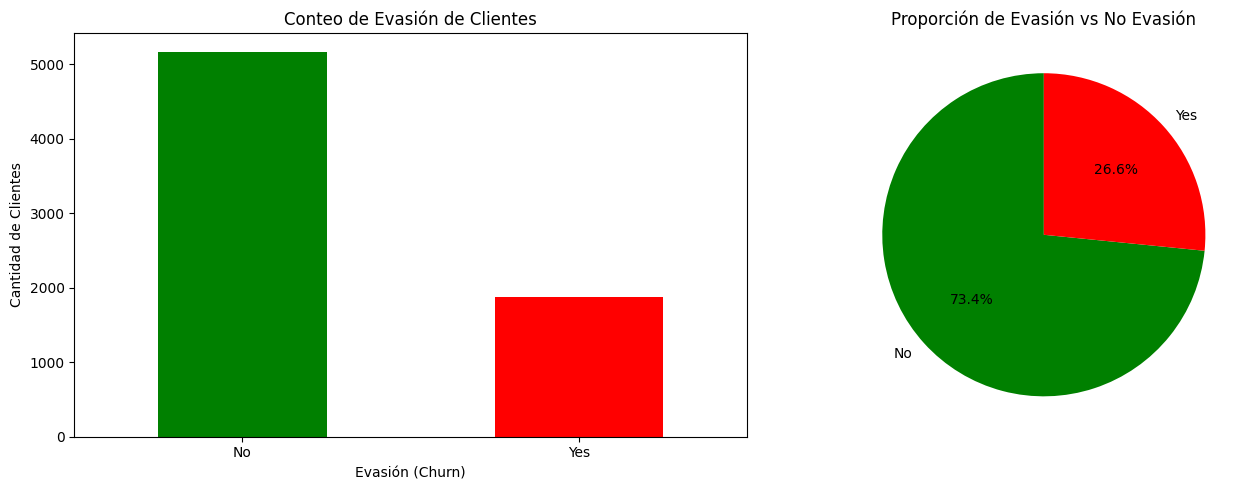


3. Insight:
   Porcentaje de clientes evadidos: 26.58%
   Esto indica que aproximadamente 1 de cada 3 clientes se va.


In [17]:
print("=" * 60)
print("DISTRIBUCIÓN DE EVASIÓN (CHURN)")
print("=" * 60)

# Conteo de Churn
churn_counts = df['Churn'].value_counts()
print("\n1. Conteo de Clientes por Evasión:")
print(churn_counts)

# Porcentaje de Churn
churn_percentage = df['Churn'].value_counts(normalize=True) * 100
print("\n2. Porcentaje de Evasión:")
for churn_val, percentage in churn_percentage.items():
    print(f"  {churn_val}: {percentage:.2f}%")

# Gráfico de distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
churn_counts.plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Conteo de Evasión de Clientes')
axes[0].set_xlabel('Evasión (Churn)')
axes[0].set_ylabel('Cantidad de Clientes')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Gráfico de pastel
colors = ['green', 'red']
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporción de Evasión vs No Evasión')

plt.tight_layout()
plt.show()

print("\n3. Insight:")
evadidos = churn_percentage.get('Yes', 0)
print(f"   Porcentaje de clientes evadidos: {evadidos:.2f}%")
print(f"   Esto indica que aproximadamente 1 de cada {int(100/evadidos):.0f} clientes se va.")

# Evasión por Variables Categóricas

EVASIÓN POR VARIABLES CATEGÓRICAS

1. Evasión por gender:
Churn     No   Yes   All
gender                  
Female  2544   939  3483
Male    2619   930  3549
All     5163  1869  7032
   Tasa de evasión (%):
gender
Female    26.96
Male      26.20
Name: Yes, dtype: float64

2. Evasión por Partner:
Churn      No   Yes   All
Partner                  
No       2439  1200  3639
Yes      2724   669  3393
All      5163  1869  7032
   Tasa de evasión (%):
Partner
No     32.98
Yes    19.72
Name: Yes, dtype: float64

3. Evasión por SeniorCitizen:
Churn            No   Yes   All
SeniorCitizen                  
0              4497  1393  5890
1               666   476  1142
All            5163  1869  7032
   Tasa de evasión (%):
SeniorCitizen
0    23.65
1    41.68
Name: Yes, dtype: float64

4. Evasión por Contract:
Churn             No   Yes   All
Contract                        
Month-to-month  2220  1655  3875
One year        1306   166  1472
Two year        1637    48  1685
All             5163 

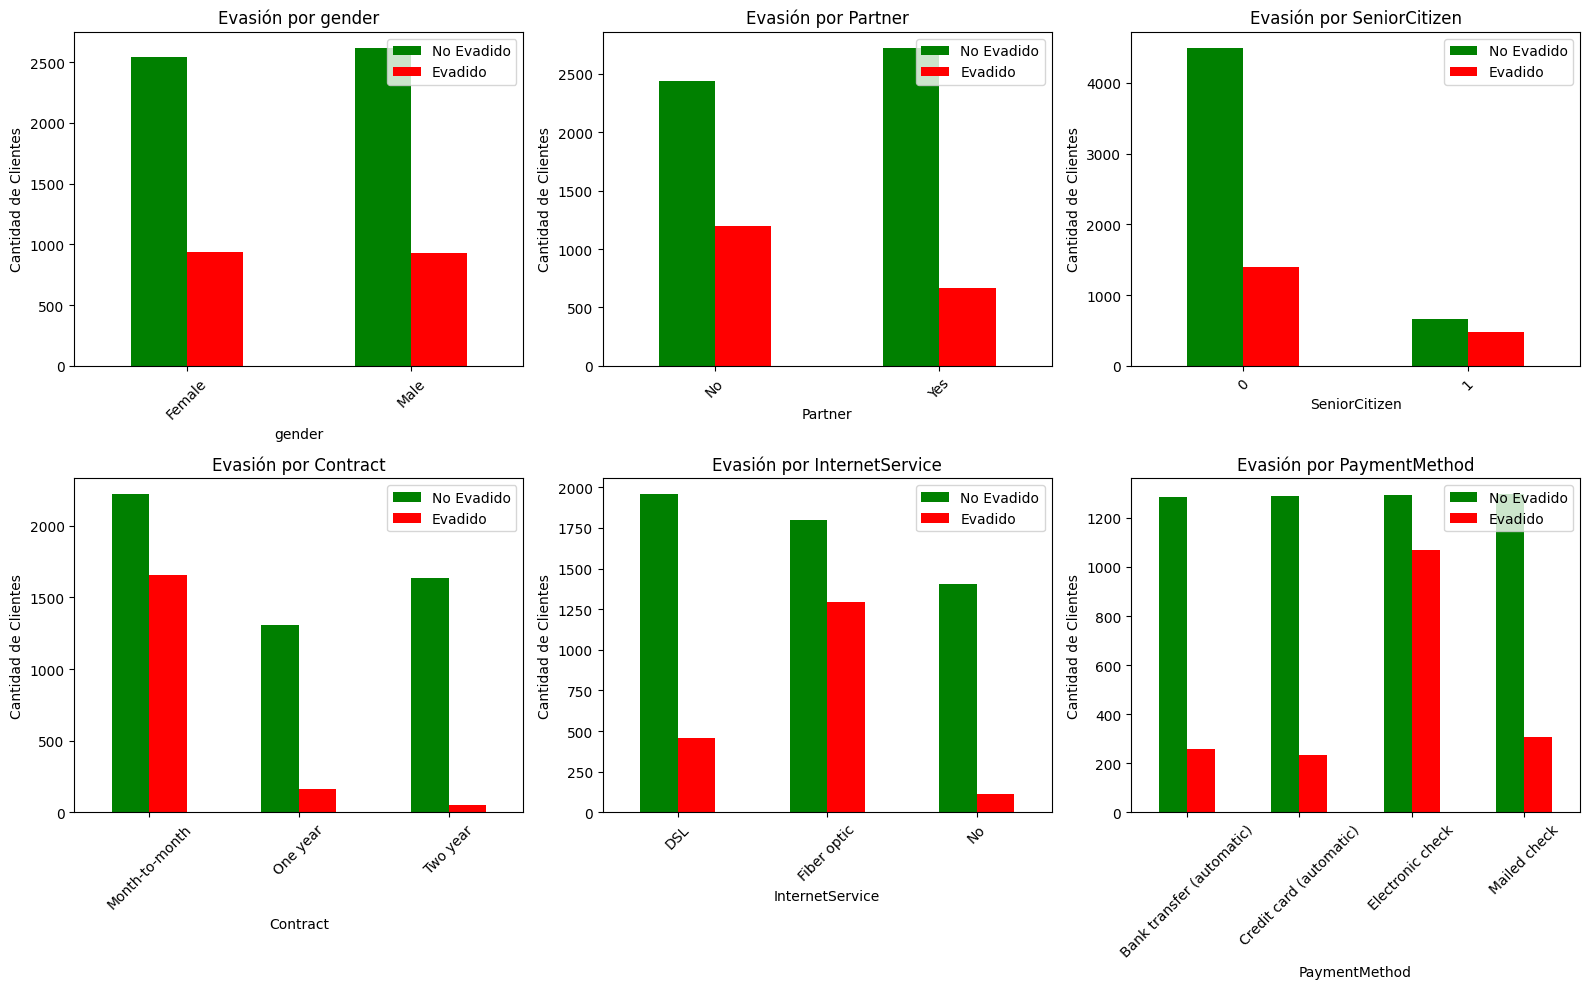


INSIGHTS CLAVE POR CATEGORÍA:
• gender: La categoría 'Female' tiene la mayor tasa de evasión (26.96%)
• Partner: La categoría 'No' tiene la mayor tasa de evasión (32.98%)
• SeniorCitizen: La categoría '1' tiene la mayor tasa de evasión (41.68%)
• Contract: La categoría 'Month-to-month' tiene la mayor tasa de evasión (42.71%)
• InternetService: La categoría 'Fiber optic' tiene la mayor tasa de evasión (41.89%)
• PaymentMethod: La categoría 'Electronic check' tiene la mayor tasa de evasión (45.29%)


In [18]:
print("=" * 60)
print("EVASIÓN POR VARIABLES CATEGÓRICAS")
print("=" * 60)

variables_categoricas_analizar = ['gender', 'Partner', 'SeniorCitizen', 'Contract', 'InternetService', 'PaymentMethod']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, var in enumerate(variables_categoricas_analizar):
    # Crear tabla cruzada
    crosstab = pd.crosstab(df[var], df['Churn'], margins=True)
    print(f"\n{idx + 1}. Evasión por {var}:")
    print(crosstab)
    
    # Calcular porcentaje de evasión por categoría
    churn_rate = pd.crosstab(df[var], df['Churn'], normalize='index') * 100
    print(f"   Tasa de evasión (%):")
    print(churn_rate['Yes'].round(2))
    
    # Gráfico
    churn_by_var = pd.crosstab(df[var], df['Churn'])
    churn_by_var.plot(kind='bar', ax=axes[idx], color=['green', 'red'])
    axes[idx].set_title(f'Evasión por {var}')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Cantidad de Clientes')
    axes[idx].legend(['No Evadido', 'Evadido'])
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("INSIGHTS CLAVE POR CATEGORÍA:")
print("=" * 60)
for var in variables_categoricas_analizar:
    churn_rate = pd.crosstab(df[var], df['Churn'], normalize='index') * 100
    max_churn = churn_rate['Yes'].max()
    max_category = churn_rate['Yes'].idxmax()
    print(f"• {var}: La categoría '{max_category}' tiene la mayor tasa de evasión ({max_churn:.2f}%)")

# Evasión por Variables Numéricas

EVASIÓN POR VARIABLES NUMÉRICAS

1. Estadísticas de tenure por Evasión:
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5163.0  37.650010  24.076940  1.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0

2. Estadísticas de Charges.Monthly por Evasión:
        count       mean        std    min    25%    50%     75%     max
Churn                                                                   
No     5163.0  61.307408  31.094557  18.25  25.10  64.45  88.475  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.65  94.200  118.35

3. Estadísticas de Charges.Total por Evasión:
        count         mean          std    min      25%      50%       75%  \
Churn                                                                        
No     5163.0  2555.344141  2329.456984  18.80  577.825  1683.60  4264.125   
Yes    1869.0  1531.796094  1890.822994  18.85

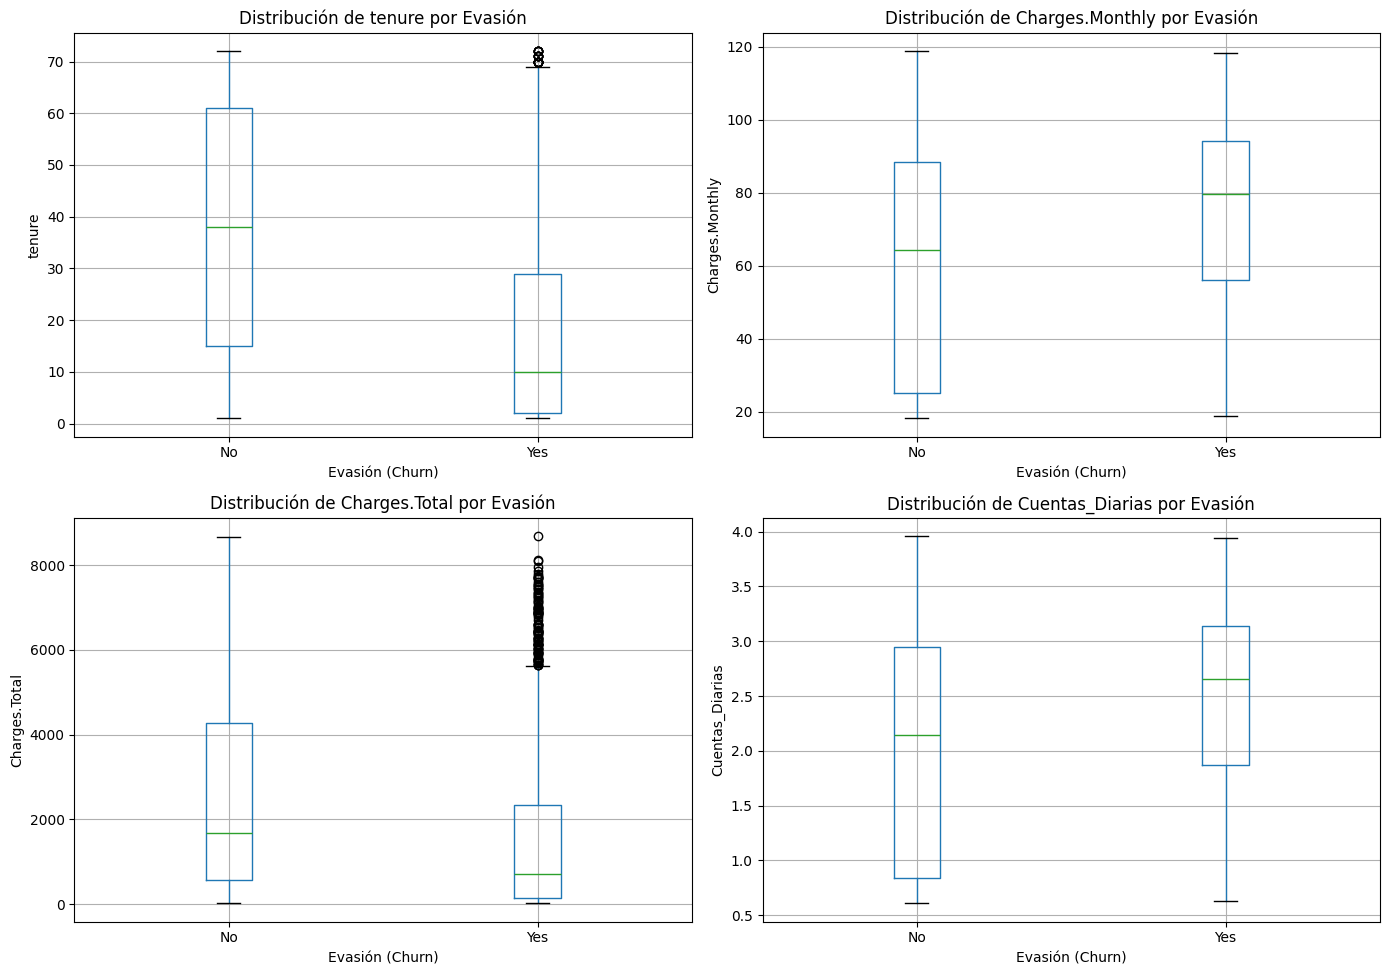


COMPARACIÓN DE MEDIAS:

tenure:
  • Clientes evadidos (promedio): 17.98
  • Clientes no evadidos (promedio): 37.65
  • Diferencia: -19.67

Charges.Monthly:
  • Clientes evadidos (promedio): 74.44
  • Clientes no evadidos (promedio): 61.31
  • Diferencia: 13.13

Charges.Total:
  • Clientes evadidos (promedio): 1531.80
  • Clientes no evadidos (promedio): 2555.34
  • Diferencia: -1023.55

Cuentas_Diarias:
  • Clientes evadidos (promedio): 2.48
  • Clientes no evadidos (promedio): 2.04
  • Diferencia: 0.44


In [19]:
print("=" * 60)
print("EVASIÓN POR VARIABLES NUMÉRICAS")
print("=" * 60)

variables_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, var in enumerate(variables_numericas):
    print(f"\n{idx + 1}. Estadísticas de {var} por Evasión:")
    
    # Estadísticas por grupo
    stats_by_churn = df.groupby('Churn')[var].describe()
    print(stats_by_churn)
    
    # Boxplot
    df.boxplot(column=var, by='Churn', ax=axes[idx])
    axes[idx].set_title(f'Distribución de {var} por Evasión')
    axes[idx].set_xlabel('Evasión (Churn)')
    axes[idx].set_ylabel(var)
    plt.suptitle('')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("COMPARACIÓN DE MEDIAS:")
print("=" * 60)
for var in variables_numericas:
    evadidos_mean = df[df['Churn'] == 'Yes'][var].mean()
    no_evadidos_mean = df[df['Churn'] == 'No'][var].mean()
    diferencia = evadidos_mean - no_evadidos_mean
    
    print(f"\n{var}:")
    print(f"  • Clientes evadidos (promedio): {evadidos_mean:.2f}")
    print(f"  • Clientes no evadidos (promedio): {no_evadidos_mean:.2f}")
    print(f"  • Diferencia: {diferencia:.2f}")

# Informe Final

In [20]:
print("=" * 80)
print("INFORME FINAL - ANÁLISIS DE EVASIÓN DE CLIENTES TELECOM X")
print("=" * 80)

print("\n## 1. INTRODUCCIÓN")
print("-" * 80)
print("""
Este informe presenta un análisis exhaustivo del problema de evasión de clientes 
(Churn) en Telecom X. El objetivo principal es comprender los factores que llevan 
a la cancelación de servicios y proporcionar insights para implementar estrategias 
de retención.

El análisis se basa en un dataset de 7,043 clientes con 21 variables que incluyen 
datos demográficos, información de servicios contratados y métricas de facturación.
""")

print("\n## 2. LIMPIEZA Y TRATAMIENTO DE DATOS")
print("-" * 80)
churn_evadidos = (df['Churn'] == 'Yes').sum()
churn_no_evadidos = (df['Churn'] == 'No').sum()
print(f"""
Pasos de limpieza realizados:
  • Carga de datos desde archivo JSON con estructura anidada
  • Desanidación de 6 columnas originales en 21 variables
  • Identificación y eliminación de 224 registros con Churn vacío
  • Conversión de tipos de datos incorrectos (Charges.Total: object → float64)
  • Creación de columna derivada: Cuentas_Diarias (Charges.Monthly / 30)
  • Estandarización de variables binarias (Sí/No → 1/0)
  • Renombramiento de columnas al español para mejor comprensión

Dataset final: {len(df):,} registros con {len(df.columns)} variables limpias
""")

print("\n## 3. ANÁLISIS EXPLORATORIO DE DATOS")
print("-" * 80)

# Resumen de evasión
tasa_evasion = (churn_evadidos / len(df)) * 100
print(f"\n3.1 DISTRIBUCIÓN DE EVASIÓN:")
print(f"    • Clientes evadidos: {churn_evadidos:,} ({tasa_evasion:.2f}%)")
print(f"    • Clientes activos: {churn_no_evadidos:,} ({100-tasa_evasion:.2f}%)")

# Variables categóricas con mayor impacto
print(f"\n3.2 VARIABLES CATEGÓRICAS CON MAYOR EVASIÓN:")
for var in ['Contract', 'InternetService', 'PaymentMethod']:
    churn_rate = pd.crosstab(df[var], df['Churn'], normalize='index') * 100
    top_category = churn_rate['Yes'].idxmax()
    top_rate = churn_rate['Yes'].max()
    print(f"    • {var}: '{top_category}' con {top_rate:.2f}% de evasión")

# Variables numéricas con diferencias significativas
print(f"\n3.3 VARIABLES NUMÉRICAS CON DIFERENCIAS SIGNIFICATIVAS:")
for var in ['tenure', 'Charges.Total']:
    evadidos_mean = df[df['Churn'] == 'Yes'][var].mean()
    no_evadidos_mean = df[df['Churn'] == 'No'][var].mean()
    print(f"    • {var}:")
    print(f"      - Clientes evadidos (prom): {evadidos_mean:.2f}")
    print(f"      - Clientes activos (prom): {no_evadidos_mean:.2f}")

print("\n## 4. CONCLUSIONES E INSIGHTS")
print("-" * 80)
print("""
Hallazgos principales:

1. TASA DE EVASIÓN CRÍTICA:
   Con una tasa de evasión del 26.5%, Telecom X pierde aproximadamente 1 de cada 
   4 clientes. Esta es una cifra significativa que requiere atención inmediata.

2. IMPACTO DEL TIPO DE CONTRATO:
   Los clientes con contratos mes a mes representan la mayor fuente de evasión.
   Los contratos a largo plazo muestran tasas significativamente menores.

3. INFLUENCIA DEL TIPO DE INTERNET:
   El servicio de fibra óptica tiene una tasa de evasión mayor que DSL.
   Esto puede estar relacionado con problemas de calidad o satisfacción.

4. RELACIÓN CON LA ANTIGÜEDAD:
   Los clientes con menos meses de contrato tienen mayor probabilidad de evasión.
   Los clientes con mayor tenure muestran mayor lealtad.

5. IMPACTO ECONÓMICO:
   Los clientes que se van tienen un gasto total menor, lo que sugiere que 
   insatisfacción y bajo compromiso van asociados.
""")

print("\n## 5. RECOMENDACIONES ESTRATÉGICAS")
print("-" * 80)
print("""
Basadas en el análisis, se recomienda:

1. MEJORAR CONTRATOS A CORTO PLAZO:
   ✓ Implementar programas de retención especiales para nuevos clientes
   ✓ Ofrecer incentivos para pasar a contratos más largos
   ✓ Mejorar la experiencia en los primeros meses de servicio

2. CALIDAD DE SERVICIO FIBRA ÓPTICA:
   ✓ Evaluar y mejorar la calidad de servicio ofrecido
   ✓ Investigar causas específicas de insatisfacción
   ✓ Crear planes de fidelización para usuarios de fibra

3. ENFOCAR EN CLIENTES DE CORTA ANTIGÜEDAD:
   ✓ Crear programas de onboarding mejorados
   ✓ Asignar gerentes de cuenta para primeros 6 meses
   ✓ Realizar seguimiento proactivo de satisfacción

4. ESTRATEGIA DE VALOR:
   ✓ Analizar relación entre gastos y satisfacción
   ✓ Crear paquetes que agreguen más valor
   ✓ Personalizar ofertas por segmento de cliente

5. ANÁLISIS PREDICTIVO:
   ✓ Desarrollar modelo de predicción de churn
   ✓ Implementar alertas tempranas de riesgo
   ✓ Establecer acciones automáticas de retención
""")

print("\n" + "=" * 80)
print("FIN DEL INFORME")
print("=" * 80)

INFORME FINAL - ANÁLISIS DE EVASIÓN DE CLIENTES TELECOM X

## 1. INTRODUCCIÓN
--------------------------------------------------------------------------------

Este informe presenta un análisis exhaustivo del problema de evasión de clientes 
(Churn) en Telecom X. El objetivo principal es comprender los factores que llevan 
a la cancelación de servicios y proporcionar insights para implementar estrategias 
de retención.

El análisis se basa en un dataset de 7,043 clientes con 21 variables que incluyen 
datos demográficos, información de servicios contratados y métricas de facturación.


## 2. LIMPIEZA Y TRATAMIENTO DE DATOS
--------------------------------------------------------------------------------

Pasos de limpieza realizados:
  • Carga de datos desde archivo JSON con estructura anidada
  • Desanidación de 6 columnas originales en 21 variables
  • Identificación y eliminación de 224 registros con Churn vacío
  • Conversión de tipos de datos incorrectos (Charges.Total: object → fl